# Unsupervised Learning

## Objective

The objective of this analysis is to identify distinct types of prediction markets on Polymarket using unsupervised machine learning techniques. By clustering markets with similar characteristics, we aim to uncover hidden market structures and evaluate whether these clusters provide meaningful insights for later prediction tasks.

## Methodology

The analysis follows the following workflow:

1. **Load and inspect the cleaned dataset** to ensure the data is suitable for clustering.
2. **Select relevant clustering features**, including market duration, reward size, market categories, and outcome formats.
3. **Standardize numerical variables** while keeping binary variables unchanged.
4. **Apply K-Means clustering** and determine the optimal number of clusters using the **Elbow Method** and **Silhouette Score**.
5. **Interpret the resulting clusters** by comparing their average characteristics and visualizing them using Principal Component Analysis (PCA).
6. **Apply Hierarchical Clustering** and use the dendrogram to further investigate the underlying market structure.
7. **Export for Subsequent Analyses** to evaluate whether market segmentation improves the prediction of trading volume.

# 1. Data and Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mglearn
from IPython import display
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, ward, average
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler


In [144]:
# loading the data from the CSV file

df_markets = pd.read_csv("polymarkets_data_cleaned.csv")

print(df_markets.shape)

(175049, 32)


In [145]:
# have a look at the data types and null values in the dataset

df_markets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175049 entries, 0 to 175048
Data columns (total 32 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    175049 non-null  int64  
 1   question              175049 non-null  object 
 2   startDateIso          175049 non-null  object 
 3   endDateIso            175049 non-null  object 
 4   volume                175049 non-null  float64
 5   liquidity             44504 non-null   float64
 6   outcomes              175049 non-null  object 
 7   outcomePrices         175049 non-null  object 
 8   rewardsMinSize        175049 non-null  float64
 9   restricted            175049 non-null  int64  
 10  spread_poly           175049 non-null  float64
 11  bestBid               81596 non-null   float64
 12  bestAsk               175035 non-null  float64
 13  spread                81583 non-null   float64
 14  politics              175049 non-null  int64  
 15  


# 2. Select relevant clustering features

**Selected clustering features:** `duration`, `rewardsMinSize`, `politics`, `sports`, `esports`, `crypto`, `finance`, `business`, `technology_ai`, `geopolitics`, `culture`, `science`, `number_of_categories`, `outcome_yes_no`, `outcome_up_down`, `outcome_over_under`, `outcome_other`

In [147]:
numerical_features = [
    "duration",
    "rewardsMinSize",
    "number_of_categories"
]

dummy_features = [
    "politics",
    "sports",
    "esports",
    "crypto",
    "finance",
    "business",
    "technology_ai",
    "geopolitics",
    "culture",
    "science",
    "outcome_yes_no",
    "outcome_up_down",
    "outcome_over_under",
    "outcome_other"
]

# 3. Standardize numerical variables while keeping binary variables unchanged

In [ ]:
scaler = StandardScaler()

X_num = pd.DataFrame(
    scaler.fit_transform(df_markets[numerical_features]),
    columns=numerical_features,
    index=df_markets.index
)

In [149]:
X_dummy = df_markets[dummy_features]

In [150]:
X = pd.concat([X_num, X_dummy], axis=1)

# 4. **Apply K-Means clustering** and determine the optimal number of clusters using the **Elbow Method** and **Silhouette Score**.

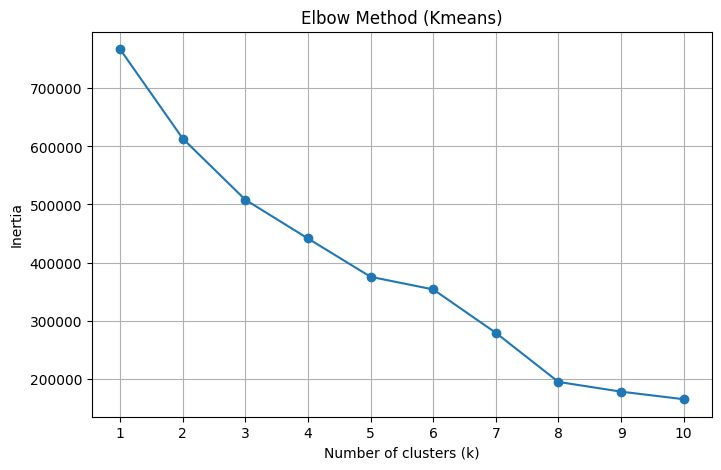

In [151]:
# Elbow Method
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (Kmeans)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

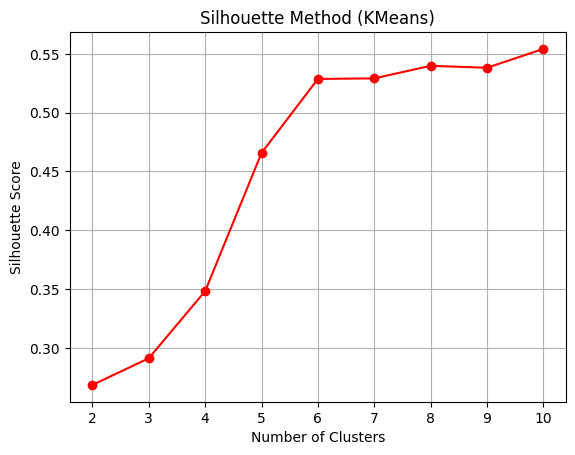

In [34]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot Silhouette Scores
plt.figure()
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method (KMeans)')
plt.grid(True)
plt.show()
plt.show()

### Choosing the Number of Clusters

To determine the appropriate number of clusters for K-Means, we combined the **Elbow Method** and the **Silhouette Score**.

The Elbow Method indicates noticeable elbows at **k = 3** and **k = 5**, suggesting that both values provide meaningful clustering solutions. The Silhouette Score further supports this observation, with **k = 5** outperforming **k = 3**. Moreover, the Silhouette Score continues to increase for even larger values of *k*, indicating that additional clusters could potentially improve cluster separation.

However, we deliberately restrict the K-Means analysis to **k = 3** and **k = 5**. Larger numbers of clusters are instead explored in the subsequent **Hierarchical Clustering** analysis, where the dendrogram provides a more suitable framework for investigating more detailed cluster structures. This allows us to compare both clustering approaches while avoiding unnecessary overlap in the K-Means analysis.

# 5. Interpret the resulting clusters by comparing their average characteristics and visualizing them using Principal Component Analysis (PCA).

## k = 3

In [152]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_markets["cluster_kmeans_3"] = kmeans.fit_predict(X)

print(df_markets["cluster_kmeans_3"].value_counts().sort_index())

cluster_kmeans_3
0     10678
1     52374
2    111997
Name: count, dtype: int64


In [153]:
df_markets.groupby("cluster_kmeans_3")[numerical_features + dummy_features].mean().round(2)

,duration,rewardsMinSize,number_of_categories,politics,sports,esports,crypto,finance,business,technology_ai,geopolitics,culture,science,outcome_yes_no,outcome_up_down,outcome_over_under,outcome_other
cluster_kmeans_3,,,,,,,,,,,,,,,,,
0,218.19,60.58,0.99,0.29,0.42,0.03,0.05,0.04,0.04,0.02,0.04,0.07,0.01,0.99,0.00,0.00,0.01
1,9.06,7.25,0.36,0.00,0.31,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.34,0.00,0.10,0.56
2,8.06,12.83,1.24,0.09,0.24,0.03,0.55,0.02,0.19,0.01,0.02,0.04,0.04,0.54,0.37,0.07,0.02


### Cluster interpretation

Based on the selected features, the K-Means algorithm identifies three distinct types of prediction markets:

| Cluster | Interpretation | Main Characteristics |
|---------|----------------|----------------------|
| **0** | **Long-term political and sports markets** | Very long duration, highest rewards, mainly politics and sports, almost exclusively Yes/No markets. |
| **1** | **Short uncategorized markets** | Short duration, low rewards, few assigned market categories, dominated by Other outcome formats with some sports markets. |
| **2** | **Short crypto and business markets** | Short duration, moderate rewards, dominated by crypto markets with additional business markets, mainly Yes/No and Up/Down outcome formats. |

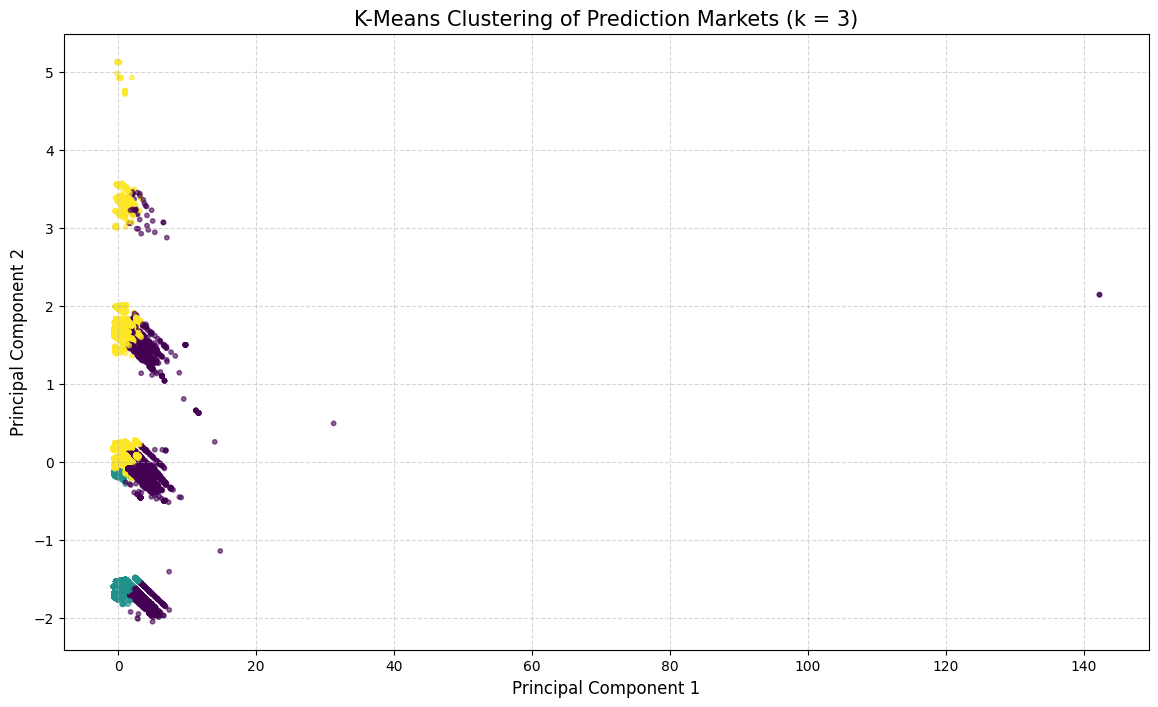

In [154]:
# Visualize the clusters using Principal Component Analysis (PCA)
# Reduce the feature matrix to two principal components
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# Initialize the plot
plt.figure(figsize=(14, 8))

# Scatter plot of the first two principal components
plt.scatter(coords[:, 0], coords[:, 1],
            c=df_markets["cluster_kmeans_3"],
            cmap="viridis",
            s=10,
            alpha=0.6)

# Configure plot
plt.title("K-Means Clustering of Prediction Markets (k = 3)", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

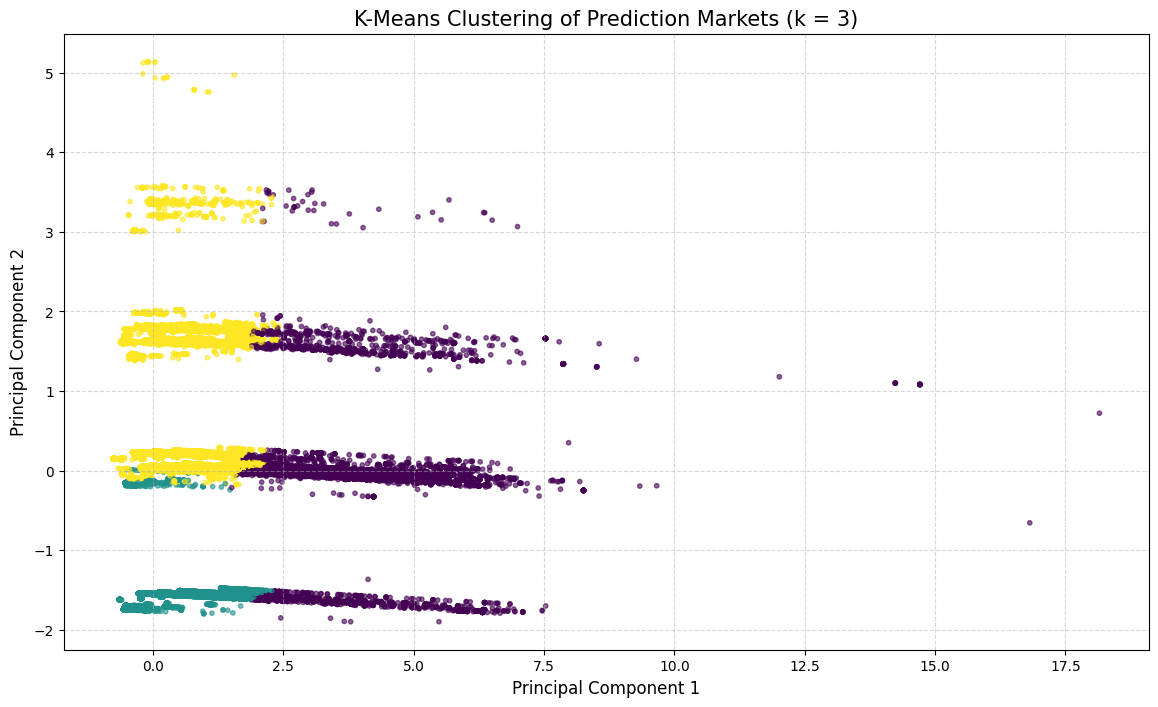

In [155]:
# Remove the two extreme outliers for visualization only
mask = df_markets["rewardsMinSize"] < 10000
X_plot = X[mask]
clusters_plot = df_markets.loc[mask, "cluster_kmeans_3"]

# Visualize the clusters using Principal Component Analysis (PCA)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_plot)

# Initialize the plot
plt.figure(figsize=(14, 8))

# Scatter plot of the first two principal components
plt.scatter(coords[:, 0], coords[:, 1],
            c=clusters_plot,
            cmap="viridis",
            s=10,
            alpha=0.6)

# Configure plot
plt.title("K-Means Clustering of Prediction Markets (k = 3)", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

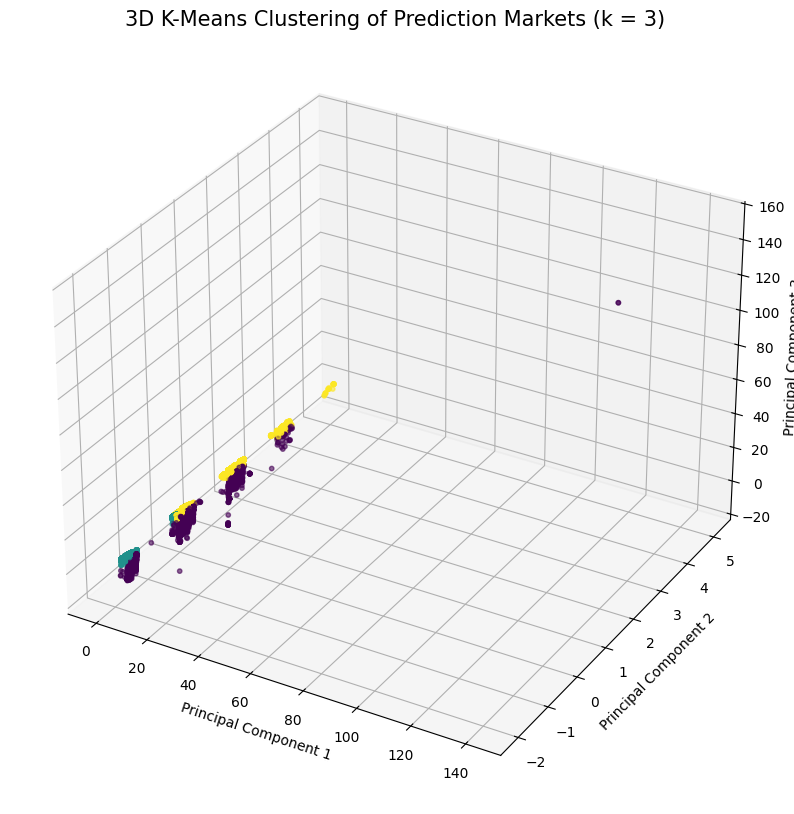

In [156]:
# Increase dimensionality reduction to three principal components
pca = PCA(n_components=3)
coords = pca.fit_transform(X)

# Setup the 3D plotting environment
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Generate a 3D scatter plot
ax.scatter(coords[:, 0],
           coords[:, 1],
           coords[:, 2],
           c=df_markets["cluster_kmeans_3"],
           cmap="viridis",
           s=10,
           alpha=0.6)

# Configure plot
ax.set_title("3D K-Means Clustering of Prediction Markets (k = 3)", fontsize=15)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

plt.show()

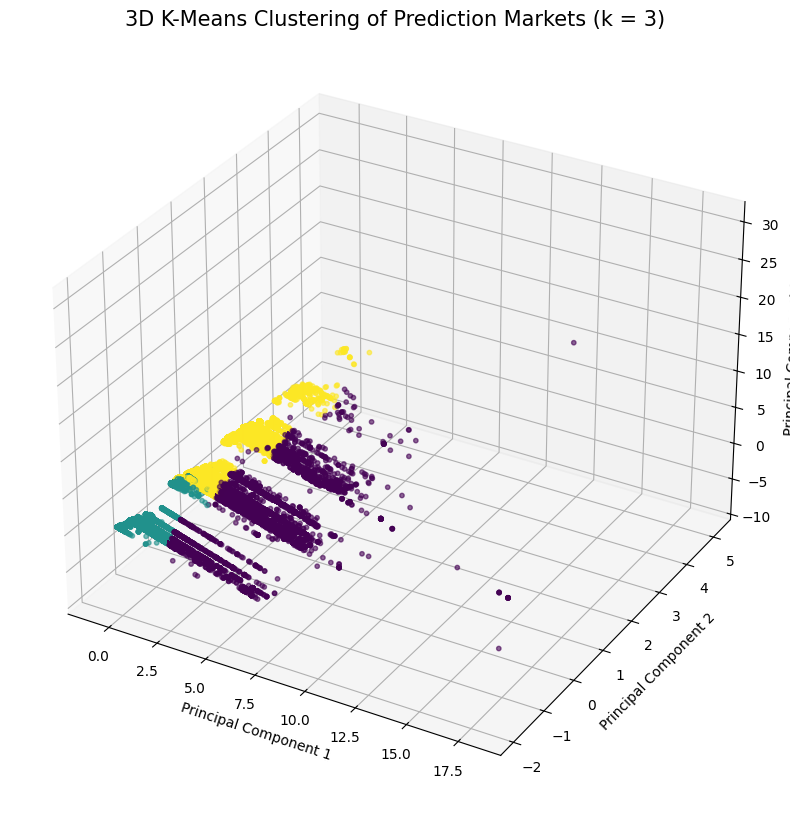

In [157]:
# Remove the two extreme outliers for visualization only
mask = df_markets["rewardsMinSize"] < 10000
X_plot = X[mask]
clusters_plot = df_markets.loc[mask, "cluster_kmeans_3"]

# Reduce the feature matrix to three principal components
pca = PCA(n_components=3)
coords = pca.fit_transform(X_plot)

# Setup the 3D plotting environment
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Generate a 3D scatter plot
ax.scatter(coords[:, 0],
           coords[:, 1],
           coords[:, 2],
           c=clusters_plot,
           cmap="viridis",
           s=10,
           alpha=0.6)

# Configure plot
ax.set_title("3D K-Means Clustering of Prediction Markets (k = 3)", fontsize=15)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

plt.show()

## k = 5

In [158]:
kmeans = KMeans(n_clusters=5, random_state=42)
df_markets["cluster_kmeans_5"] = kmeans.fit_predict(X)

print(df_markets["cluster_kmeans_5"].value_counts().sort_index())

cluster_kmeans_5
0     9161
1    33459
2    30486
3    59352
4    42591
Name: count, dtype: int64


In [159]:
df_markets.groupby("cluster_kmeans_5")[numerical_features + dummy_features].mean().round(2)

,duration,rewardsMinSize,number_of_categories,politics,sports,esports,crypto,finance,business,technology_ai,geopolitics,culture,science,outcome_yes_no,outcome_up_down,outcome_over_under,outcome_other
cluster_kmeans_5,,,,,,,,,,,,,,,,,
0,236.08,56.38,1.00,0.30,0.46,0.03,0.05,0.04,0.03,0.01,0.03,0.05,0.00,0.99,0.00,0.00,0.01
1,11.63,9.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.53,0.01,0.15,0.31
2,22.34,51.28,1.20,0.33,0.13,0.02,0.09,0.08,0.17,0.03,0.07,0.12,0.15,0.96,0.02,0.00,0.01
3,2.49,0.38,1.27,0.00,0.00,0.00,0.99,0.00,0.27,0.00,0.00,0.00,0.00,0.31,0.69,0.00,0.00
4,7.68,1.22,1.11,0.00,0.94,0.12,0.01,0.00,0.01,0.01,0.01,0.02,0.00,0.34,0.00,0.17,0.49


### Cluster interpretation

| Cluster | Interpretation | Main Characteristics |
|---------|----------------|----------------------|
| **0** | **Long-term political and sports markets** | Very long duration, high rewards, mainly politics and sports, almost exclusively Yes/No markets. |
| **1** | **Uncategorized short-term markets** | Medium duration, moderate rewards, no assigned market category, many alternative outcome formats (Over/Under and Other). |
| **2** | **High-reward general event markets** | Medium duration, high rewards, broad mix of categories, predominantly Yes/No markets. |
| **3** | **Short crypto price markets** | Very short duration, almost exclusively crypto markets, mainly Up/Down outcome format, very low rewards. |
| **4** | **Short sports betting markets** | Short duration, dominated by sports markets, low rewards, many Other and Over/Under outcome formats. |

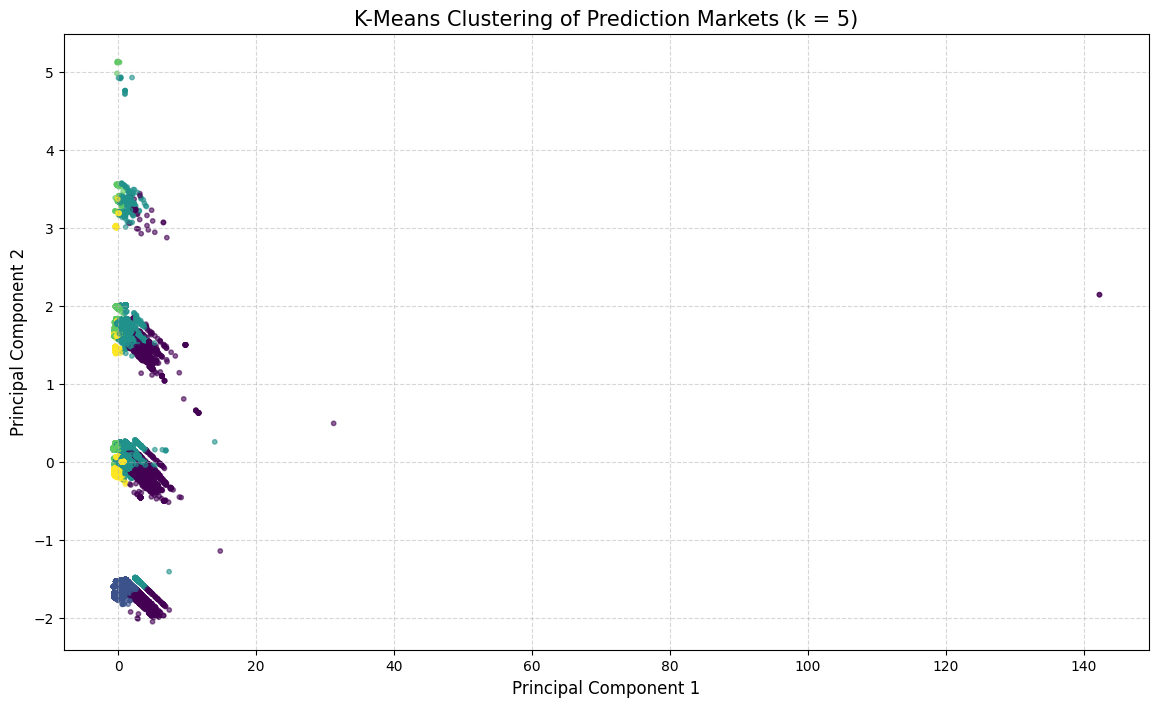

In [160]:
# Visualize the clusters using Principal Component Analysis (PCA)
# Reduce the feature matrix to two principal components
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# Initialize the plot
plt.figure(figsize=(14, 8))

# Scatter plot of the first two principal components
plt.scatter(coords[:, 0], coords[:, 1],
            c=df_markets["cluster_kmeans_5"],
            cmap="viridis",
            s=10,
            alpha=0.6)

# Configure plot
plt.title("K-Means Clustering of Prediction Markets (k = 5)", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

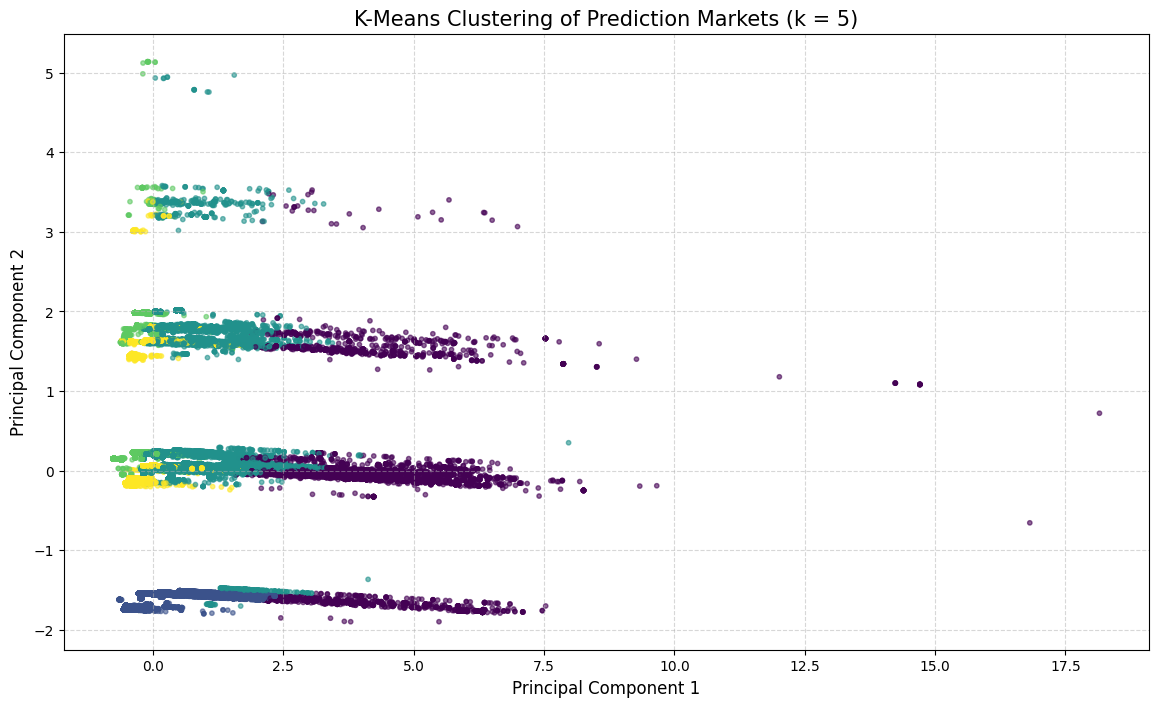

In [161]:
mask = df_markets["rewardsMinSize"] < 10000
X_plot = X[mask]
clusters_plot = df_markets.loc[mask, "cluster_kmeans_5"]

# Visualize the clusters using Principal Component Analysis (PCA)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_plot)

# Initialize the plot
plt.figure(figsize=(14, 8))

# Scatter plot of the first two principal components
plt.scatter(coords[:, 0], coords[:, 1],
            c=clusters_plot,
            cmap="viridis",
            s=10,
            alpha=0.6)

# Configure plot
plt.title("K-Means Clustering of Prediction Markets (k = 5)", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

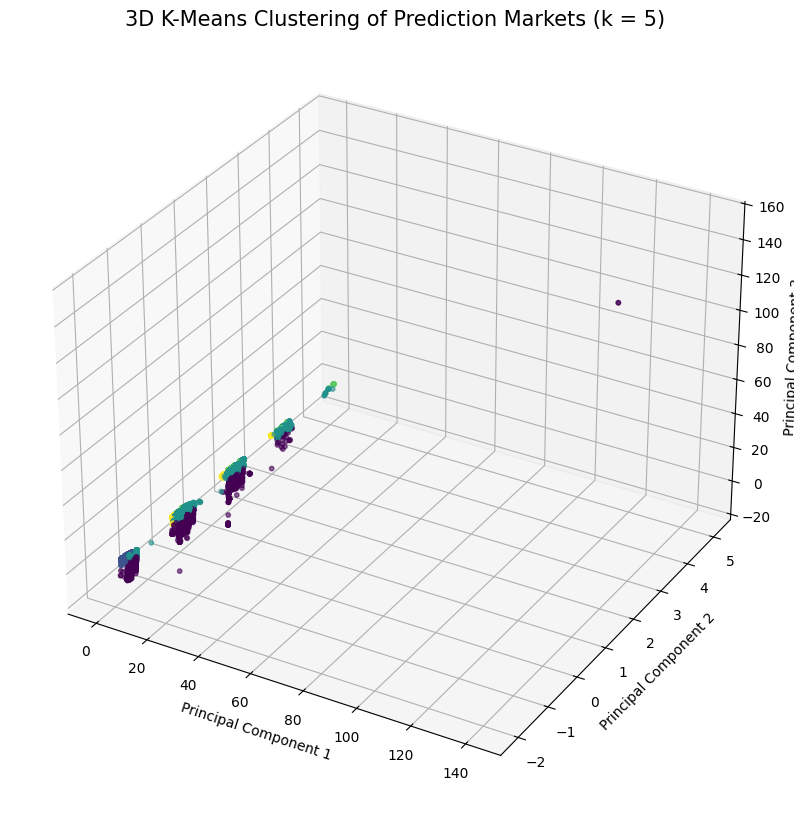

In [162]:
# Increase dimensionality reduction to three principal components
pca = PCA(n_components=3)
coords = pca.fit_transform(X)

# Setup the 3D plotting environment
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Generate a 3D scatter plot
ax.scatter(coords[:, 0],
           coords[:, 1],
           coords[:, 2],
           c=df_markets["cluster_kmeans_5"],
           cmap="viridis",
           s=10,
           alpha=0.6)

# Configure plot
ax.set_title("3D K-Means Clustering of Prediction Markets (k = 5)", fontsize=15)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

plt.show()

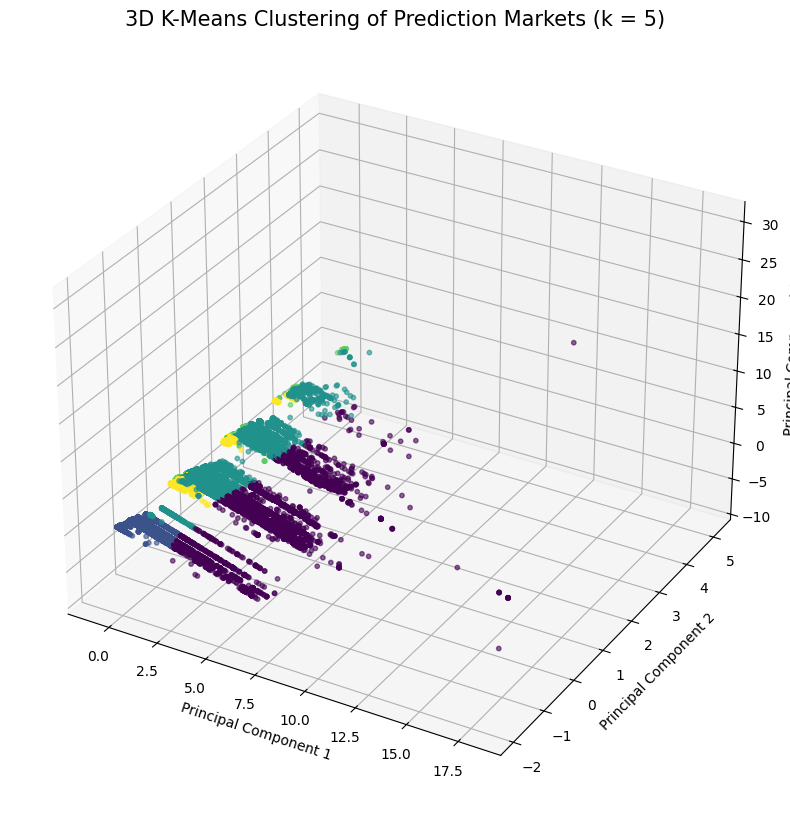

In [163]:
# Remove the two extreme outliers for visualization only
mask = df_markets["rewardsMinSize"] < 10000
X_plot = X[mask]
clusters_plot = df_markets.loc[mask, "cluster_kmeans_5"]

# Reduce the feature matrix to three principal components
pca = PCA(n_components=3)
coords = pca.fit_transform(X_plot)

# Setup the 3D plotting environment
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Generate a 3D scatter plot
ax.scatter(coords[:, 0],
           coords[:, 1],
           coords[:, 2],
           c=clusters_plot,
           cmap="viridis",
           s=10,
           alpha=0.6)

# Configure plot
ax.set_title("3D K-Means Clustering of Prediction Markets (k = 5)", fontsize=15)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

plt.show()

# 6. Apply Hierarchical Clusteringand use the dendrogram to further investigate the underlying market structure.

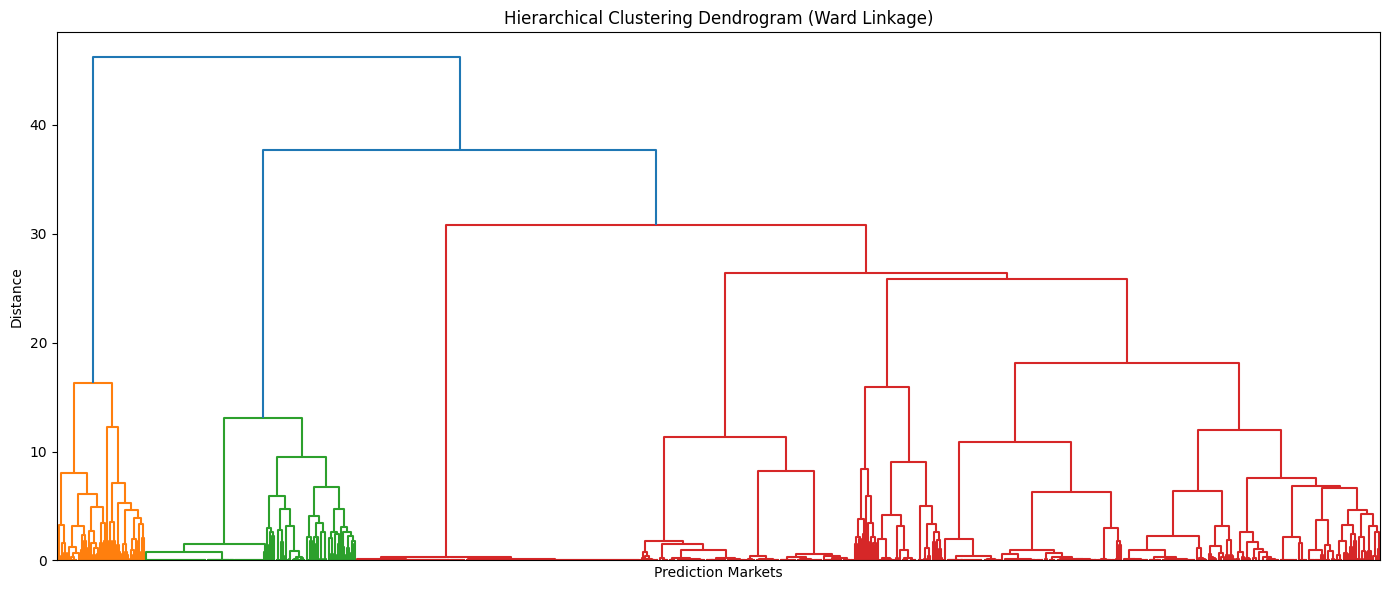

In [166]:
# Draw a random sample for visualization
sample = X.sample(n=1000, random_state=42)

# Compute Euclidean distances between markets
distance = pdist(sample, metric="euclidean")

# Hierarchical clustering using Ward linkage
linkage_matrix = linkage(distance, method="ward")

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Prediction Markets")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

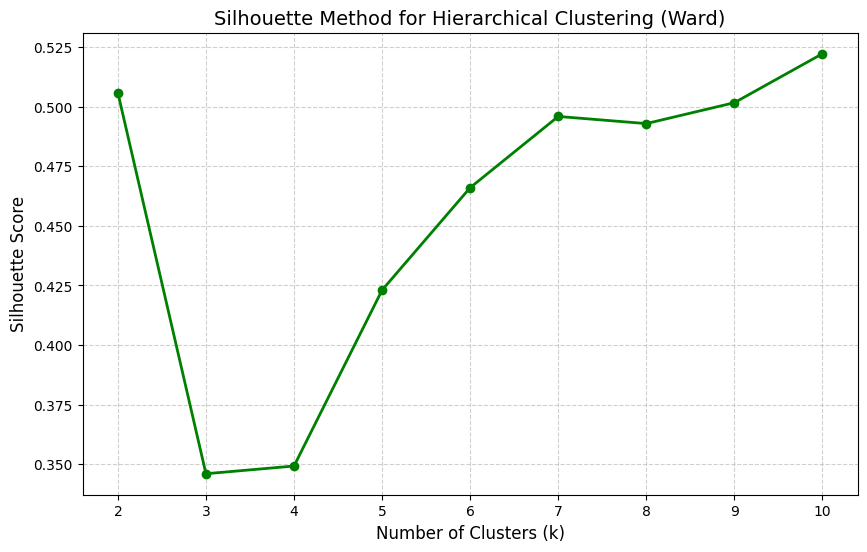

The optimal number of clusters based on the Silhouette Score is: 10


In [167]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

# Define the range for testing clusters
K_range = range(2, 11)
hierarchical_silhouette_scores = []

# Iterate through different cluster counts
for k in K_range:
    # Cut the dendrogram into k clusters
    labels = fcluster(linkage_matrix, k, criterion='maxclust')

    # Calculate the Silhouette Score
    score = silhouette_score(sample, labels)
    hierarchical_silhouette_scores.append(score)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, hierarchical_silhouette_scores, 'go-', linewidth=2)
plt.title('Silhouette Method for Hierarchical Clustering (Ward)', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Identify the optimal number of clusters
best_k = K_range[np.argmax(hierarchical_silhouette_scores)]
print(f"The optimal number of clusters based on the Silhouette Score is: {best_k}")

### Choosing the Number of Clusters

For Hierarchical Clustering, we combined information from the **dendrogram** and the **Silhouette Score** to select meaningful clustering solutions.

The dendrogram shows a clear separation at **k = 2**, indicating two highly distinct groups before the largest merge occurs. This provides a natural division of the prediction markets into two distinct groups.

The Silhouette Score reaches its highest value at **k = 2**, confirming that this solution produces the best overall cluster separation. However, the score increases again for larger values of *k*, with **k = 7** representing the strongest clustering solution beyond the two-cluster case. The dendrogram also shows meaningful substructures that support a finer partition at this level.

Therefore, we evaluate both **k = 2** and **k = 7**. The two-cluster solution captures the broadest market segmentation, while the seven-cluster solution provides a more detailed view of market characteristics. Additionally, selecting **k = 7** allows us to investigate a clustering solution that differs from those used in the K-Means analysis (*k = 3* and *k = 5*), enabling a broader comparison of clustering approaches in the subsequent supervised learning analysis.

# k=2

### Hierarchical Clustering on a Sample

Hierarchical clustering has a significantly higher computational complexity than K-Means and therefore becomes impractical for very large datasets. To ensure efficient computation while preserving the overall structure of the data, we apply the algorithm to a **random sample of 1,000 observations**. The sample is drawn using a fixed random seed (`random_state = 42`) to ensure reproducibility.

In [170]:
from sklearn.cluster import AgglomerativeClustering

# Draw a random sample
sample = X.sample(n=1000, random_state=42)

# Fit hierarchical clustering
agg = AgglomerativeClustering(n_clusters=2, linkage="ward")

# Assign cluster labels
sample_labels = agg.fit_predict(sample)

# Store results in a DataFrame
sample_results = sample.copy()
sample_results["cluster_hierarchical"] = sample_labels

# Display cluster sizes
print(sample_results["cluster_hierarchical"].value_counts().sort_index())

cluster_hierarchical
0    934
1     66
Name: count, dtype: int64


In [172]:
sample_original = df_markets.loc[sample.index].copy()
sample_original["cluster_hierarchical"] = sample_labels

sample_original.groupby("cluster_hierarchical")[numerical_features + dummy_features].mean().round(2)

,duration,rewardsMinSize,number_of_categories,politics,sports,esports,crypto,finance,business,technology_ai,geopolitics,culture,science,outcome_yes_no,outcome_up_down,outcome_over_under,outcome_other
cluster_hierarchical,,,,,,,,,,,,,,,,,
0,11.12,15.14,0.97,0.07,0.27,0.03,0.37,0.02,0.13,0.01,0.01,0.03,0.03,0.52,0.24,0.07,0.17
1,242.39,39.39,0.88,0.26,0.33,0.03,0.09,0.03,0.03,0.02,0.02,0.06,0.02,1.00,0.00,0.00,0.00


### Cluster interpretation

| Cluster | Interpretation | Main Characteristics |
|---------|----------------|----------------------|
| **0** | **Short-term mixed markets** | Short duration, moderate rewards, diverse mix of market categories with a strong presence of crypto and sports markets, multiple outcome formats (Yes/No, Up/Down, Over/Under, and Other). |
| **1** | **Long-term Yes/No markets** | Very long duration, high rewards, mainly politics and sports, exclusively Yes/No outcome format with no alternative outcome types. |

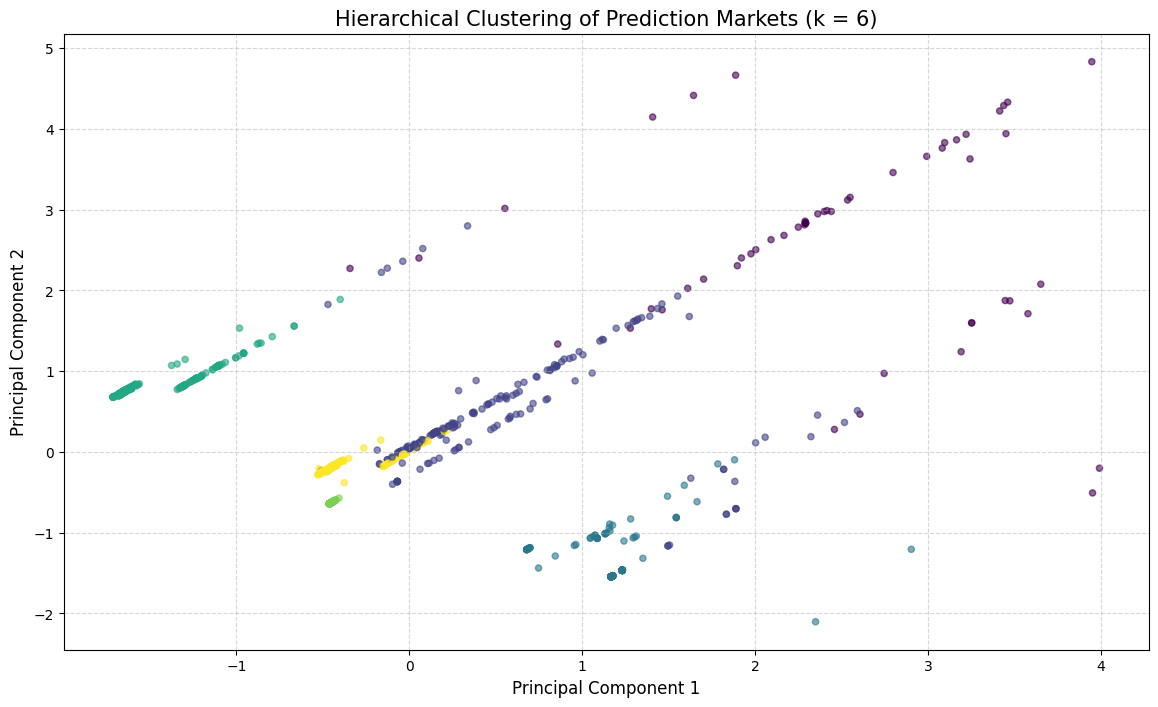

In [137]:
# Visualize the hierarchical clusters using Principal Component Analysis (PCA)
# Reduce the feature matrix to two principal components
pca = PCA(n_components=2)
coords = pca.fit_transform(sample)

# Initialize the plot
plt.figure(figsize=(14, 8))

# Scatter plot of the first two principal components
plt.scatter(coords[:, 0], coords[:, 1],
            c=sample_labels,
            cmap="viridis",
            s=20,
            alpha=0.6)

# Configure plot
plt.title("Hierarchical Clustering of Prediction Markets (k = 6)", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

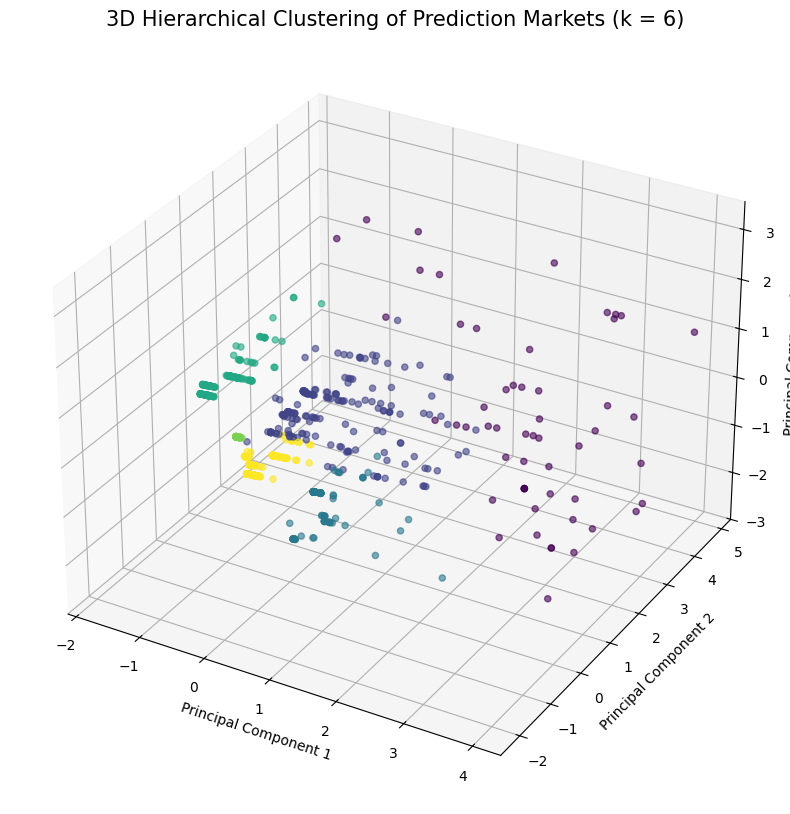

In [138]:
# Reduce the feature matrix to three principal components
pca = PCA(n_components=3)
coords = pca.fit_transform(sample)

# Setup the 3D plotting environment
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Generate a 3D scatter plot
ax.scatter(coords[:, 0],
           coords[:, 1],
           coords[:, 2],
           c=sample_labels,
           cmap="viridis",
           s=20,
           alpha=0.6)

# Configure plot
ax.set_title("3D Hierarchical Clustering of Prediction Markets (k = 6)", fontsize=15)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

plt.show()

### Assigning Hierarchical Cluster Labels to the Full Dataset

Since hierarchical clustering was performed on a random sample of 1,000 observations, the resulting cluster labels are not directly available for the remaining markets. To overcome this limitation, we train a **K-Nearest Neighbors (KNN)** classifier using the sampled observations and their hierarchical cluster labels. The trained KNN model then predicts the corresponding cluster assignment for every observation in the full dataset, allowing the hierarchical clustering results to be used in the subsequent supervised learning analysis.

In [173]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier

# Step 1 — Fit hierarchical clustering on sample only
agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
sample_labels = agg.fit_predict(sample)

# Step 2 — Train KNN on sample to learn cluster boundaries
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(sample, sample_labels)

# Step 3 — Predict cluster for full dataset
df_markets["cluster_hierarchical_2"] = knn.predict(X)

# Step 4 — Results
print(df_markets["cluster_hierarchical_2"].value_counts().sort_index())

cluster_hierarchical_2
0    166359
1      8690
Name: count, dtype: int64


In [174]:
df_markets.groupby("cluster_hierarchical_2")[numerical_features + dummy_features].mean().round(2)

,duration,rewardsMinSize,number_of_categories,politics,sports,esports,crypto,finance,business,technology_ai,geopolitics,culture,science,outcome_yes_no,outcome_up_down,outcome_over_under,outcome_other
cluster_hierarchical_2,,,,,,,,,,,,,,,,,
0,10.26,12.84,0.97,0.07,0.27,0.03,0.37,0.02,0.13,0.01,0.02,0.03,0.03,0.48,0.25,0.08,0.19
1,230.34,37.68,0.88,0.25,0.43,0.02,0.05,0.03,0.03,0.01,0.03,0.04,0.00,0.99,0.00,0.00,0.01


# k=7

In [175]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier

# Step 1 — Fit hierarchical clustering on sample only
agg = AgglomerativeClustering(n_clusters=7, linkage="ward")
sample_labels = agg.fit_predict(sample)

# Step 2 — Train KNN on sample to learn cluster boundaries
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(sample, sample_labels)

# Step 3 — Predict cluster for full dataset
df_markets["cluster_hierarchical_7"] = knn.predict(X)

# Step 4 — Results
print(df_markets["cluster_hierarchical_7"].value_counts().sort_index())

cluster_hierarchical_7
0     8749
1    35268
2     8383
3    40849
4    29259
5    26530
6    26011
Name: count, dtype: int64


In [177]:
df_markets.groupby("cluster_hierarchical_7")[numerical_features + dummy_features].mean().round(2)

,duration,rewardsMinSize,number_of_categories,politics,sports,esports,crypto,finance,business,technology_ai,geopolitics,culture,science,outcome_yes_no,outcome_up_down,outcome_over_under,outcome_other
cluster_hierarchical_7,,,,,,,,,,,,,,,,,
0,229.44,37.90,0.88,0.25,0.42,0.02,0.05,0.03,0.03,0.01,0.03,0.04,0.00,0.99,0.00,0.00,0.01
1,19.37,22.02,1.00,0.19,0.39,0.01,0.10,0.02,0.06,0.01,0.02,0.08,0.13,0.99,0.01,0.00,0.00
2,40.15,115.53,0.59,0.23,0.16,0.01,0.06,0.03,0.01,0.01,0.07,0.01,0.00,0.84,0.08,0.01,0.07
3,1.30,0.24,1.00,0.00,0.00,0.00,0.99,0.01,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
4,8.61,1.61,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.47,0.00,0.17,0.35
5,9.56,11.92,2.02,0.09,0.23,0.13,0.65,0.06,0.72,0.03,0.04,0.06,0.00,0.91,0.00,0.00,0.09
6,4.68,0.52,1.00,0.00,0.90,0.08,0.00,0.00,0.00,0.01,0.01,0.00,0.01,0.00,0.00,0.28,0.72


| Cluster | Interpretation | Main Characteristics |
|---------|----------------|----------------------|
| **0** | **Long-term political and sports markets** | Very long duration, high rewards, mainly politics and sports, almost exclusively Yes/No markets. |
| **1** | **Medium-term general event markets** | Medium duration, moderate rewards, broad mix of categories (especially politics and sports), almost exclusively Yes/No markets. |
| **2** | **High-reward special event markets** | Longest duration among short-term markets, exceptionally high rewards, relatively few categories, predominantly Yes/No markets with some alternative outcome formats. |
| **3** | **Crypto price markets** | Extremely short duration, almost exclusively crypto markets, exclusively Up/Down outcome format, very low rewards. |
| **4** | **Uncategorized short-term markets** | Short duration, very low rewards, no assigned market category, dominated by Other and Over/Under outcome formats. |
| **5** | **Crypto and business markets** | Short duration, moderate rewards, dominated by crypto and business markets, highest average number of categories, mainly Yes/No markets. |
| **6** | **Sports betting markets** | Very short duration, dominated by sports markets, minimal rewards, mainly Other and Over/Under outcome formats. |

In [178]:
df_markets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175049 entries, 0 to 175048
Data columns (total 36 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      175049 non-null  int64  
 1   question                175049 non-null  object 
 2   startDateIso            175049 non-null  object 
 3   endDateIso              175049 non-null  object 
 4   volume                  175049 non-null  float64
 5   liquidity               44504 non-null   float64
 6   outcomes                175049 non-null  object 
 7   outcomePrices           175049 non-null  object 
 8   rewardsMinSize          175049 non-null  float64
 9   restricted              175049 non-null  int64  
 10  spread_poly             175049 non-null  float64
 11  bestBid                 81596 non-null   float64
 12  bestAsk                 175035 non-null  float64
 13  spread                  81583 non-null   float64
 14  politics            

# 7. Export for Subsequent Analyses

The final cluster assignments from all clustering approaches (**K-Means with k = 3 and k = 5**, and **Hierarchical Clustering with k = 2 and k = 7**) are added to the cleaned dataset and exported as a CSV file. This enriched dataset serves as the input for the subsequent project stages.

In the supervised learning analysis, the different clustering solutions are incorporated as additional features and evaluated individually to determine which cluster representation provides the greatest improvement in predicting trading volume. This allows us to assess whether and how market segmentation contributes to predictive performance.

In [180]:
# Export the final dataset
df_markets.to_csv("data_unsupervised.csv", index=False)